####Fixed allocation strategy

read in of the data

In [16]:
# --- Data setup ---
B0 = {'X': 200, 'Y': 300, 'Z': 100}
In  = {
    'X': [350, 550, 150, 450, 200, 100, 300, 350,   0],
    'Y': [200, 200, 300, 450, 150, 100, 350, 250, 350],
    'Z': [550, 500, 500, 500, 700, 600, 400, 200, 350],
}
Out = {
    'X': [450, 250, 250, 350, 100, 300, 500, 150, 200],
    'Y': [100,   0, 600, 250, 250, 300, 150, 350, 450],
    'Z': [450, 600, 400, 400, 800, 500, 300, 400, 150],
}


The distribution for each article can be derived from the stock data


Article X distribution (periods -1…8):
 b_j   P(b_j)
 100   0.30
 200   0.10
 300   0.30
 400   0.20
 500   0.10

Article Y distribution (periods -1…8):
 b_j   P(b_j)
 200   0.20
 300   0.30
 400   0.30
 500   0.10
 600   0.10

Article Z distribution (periods -1…8):
 b_j   P(b_j)
 100   0.20
 200   0.40
 300   0.20
 400   0.20


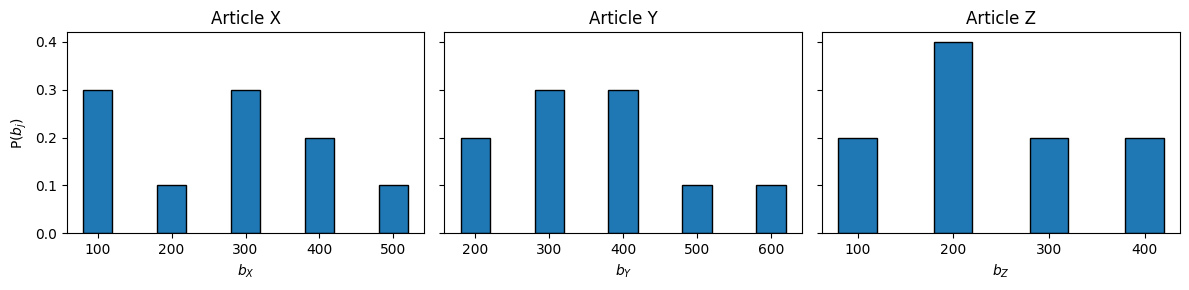

In [20]:

# Dictionary to hold the final probability distributions
distributions = {}

# --- 1) Compute and print empirical distributions ---
for art in ['X', 'Y', 'Z']:
    # 1a) Build the list of stock levels over time (periods -1…8)
    stock_levels = [B0[art]]           # start with initial stock at period -1
    current_stock = B0[art]            # track running stock level

    # For each period i = 0 to 8:
    for i in range(len(In[art])):
        # Update stock: add inflow, subtract outflow
        current_stock += #----fill
        stock_levels.append(current_stock)

    # 1b) Count how often each stock level occurs
    freq = {}  # frequency dictionary: stock_level -> count
    for level in stock_levels:
        # If level not in dict, get() returns 0, then add 1
        freq[level] = freq.get(level, 0) + 1

    # 1c) Convert frequencies to probabilities
    total_periods = len(stock_levels)  # should be 10 (period -1 through 8)
    prob = {}  # probability dictionary: stock_level -> probability
    for level, count in freq.items():
        prob[level] = count / total_periods

    # Save the distribution for later plotting
    distributions[art] = prob

    # 1d) Print the distribution table to the terminal
    print(f"\nArticle {art} distribution (periods -1…8):")
    print(" b_j   P(b_j)")
    # Sort levels so the table is in ascending order
    for level in sorted(prob):
        print(f"{level:>4}   {prob[level]:.2f}")

# --- 2) Plot all three distributions side by side ---
fig, axs = plt.subplots(1, 3, figsize=(12, 3), sharey=True)

for ax, art in zip(axs, ['X', 'Y', 'Z']):
    prob = distributions[art]
    levels = sorted(prob)                  # sorted list of stock levels
    probabilities = [prob[l] for l in levels]  # matching probabilities

    # Create a bar chart for this article
    ax.bar(levels, probabilities, width=40, edgecolor='k')
    ax.set_title(f'Article {art}')
    ax.set_xlabel(f'$b_{{{art}}}$')       # LaTeX-style label
    ax.set_xticks(levels)                 # tick at each level

# Label the shared y-axis
axs[0].set_ylabel('P($b_j$)')

# Adjust layout so labels don't overlap
plt.tight_layout()
plt.show()


The following snippet plots the stock, input and output for Article X. You can easily adjust the code to print any of the other Article plots

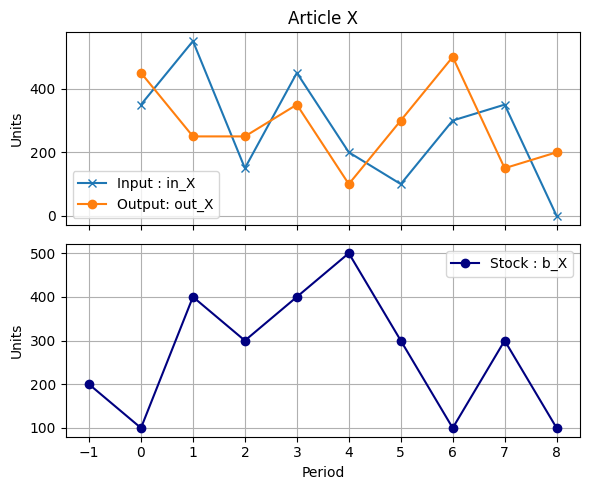

In [18]:
# --- 3) Inflow/outflow and stock time-series for Article X only ---
periods = list(range(-1, 9))
InX, OutX = In['X'], Out['X']

# compute b_X(i)
stock_X = [B0['X']]
current = B0['X']
for i in range(len(InX)):
    current += InX[i] - OutX[i]
    stock_X.append(current)

# two-panel plot for X
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 5), sharex=True)

# top: In vs Out for X (periods 0–8)
ax1.plot(periods[1:], InX,  'x-', label='Input : in_X')
ax1.plot(periods[1:], OutX, 'o-', label='Output: out_X')
ax1.set_ylabel('Units')
ax1.set_title('Article X')
ax1.legend()
ax1.grid(True)

# bottom: stock over time for X (periods -1–8)
ax2.plot(periods, stock_X, 'o-', color='navy', label='Stock : b_X')
ax2.set_xlabel('Period')
ax2.set_ylabel('Units')
ax2.legend()
ax2.grid(True)
ax2.set_xticks(periods)

plt.tight_layout()
plt.show()


Calculate the statisital security needed for the three article
For fixed allocation with overall security \(1-\alpha\), each article requires

For fixed allocation with overall security \(1-\alpha\) over \(n\) articles, each article must satisfy

$$
1 - \alpha_j \;=\;(1 - \alpha)^{\frac{1}{n}},
\quad
\alpha_j \;=\;1 - (1 - \alpha)^{\frac{1}{n}}.
$$



In [26]:
# Overall alpha and number of articles
alpha = #----fill
n = #----fill

# Per-article confidence level
per_article_conf = #----fill


print(f"(1 - α_j) = 0.95^(1/3) = {per_article_conf:.3f}")


(1 - α_j) = 0.95^(1/3) = 0.983


Calculate the cumulative distribution function


CDF for Article X:
 b_j   F(b_j)
 100   0.30
 200   0.40
 300   0.70
 400   0.90
 500   1.00

CDF for Article Y:
 b_j   F(b_j)
 200   0.20
 300   0.50
 400   0.80
 500   0.90
 600   1.00

CDF for Article Z:
 b_j   F(b_j)
 100   0.20
 200   0.60
 300   0.80
 400   1.00


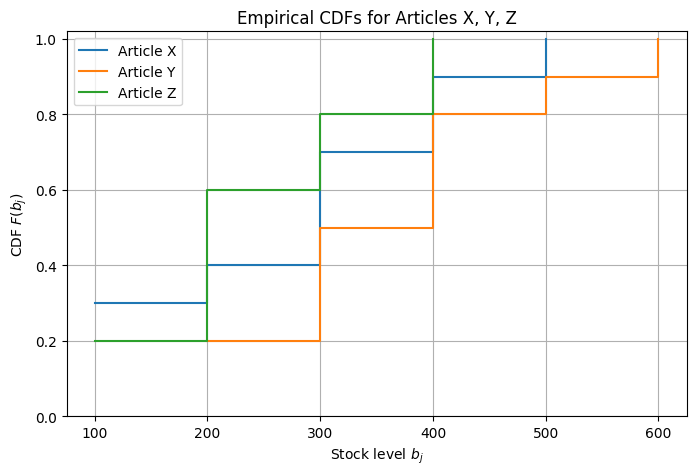

In [23]:

# 1) Print the CDF tables and also build step‐plot data
cdf_data = {}  # will hold (levels, cdf_values) for each article

for article in ['X', 'Y', 'Z']:
    print(f"\nCDF for Article {article}:")
    print(" b_j   F(b_j)")

    # Get the PDF for this article
    pdf = distributions[article]

    # Sort stock levels so we go from smallest to largest
    levels = sorted(pdf)

    cumulative = 0.0
    cdf_values = []  # to store cumulative probabilities

    # Build the CDF table
    for level in levels:
        p = pdf[level]          # probability at this level
        cumulative += p         # add to running total
        cdf_values.append(cumulative)
        print(f"{level:>4}   {cumulative:.2f}")

    # Save for plotting
    cdf_data[article] = (levels, cdf_values)

# 2) Plot the CDF step functions for all articles on one chart
plt.figure(figsize=(8,5))

for article, (levels, cdf_vals) in cdf_data.items():
    # We use 'step' to make a proper CDF plot (right‐continuous)
    plt.step(levels, cdf_vals, where='post', label=f'Article {article}')

# Chart formatting
plt.xlabel('Stock level $b_j$')
plt.ylabel('CDF $F(b_j)$')
plt.title('Empirical CDFs for Articles X, Y, Z')
plt.ylim(0, 1.02)          # show full range up to 1
plt.grid(True)
plt.legend()
plt.show()



Choose the correct amount per bin and assign it

In [25]:
# Part 1: Define required bins for each article (from fixed-allocation quantiles)
bx = #----fill  # bins needed for article X
by = #----fill  # bins needed for article Y
bz = #----fill  # bins needed for article Z

# Part 2: Compute total bins required by summing across all articles
m = #----fill

# Print the result
print(f"Total bins required (m) = {m}")


Total bins required (m) = 1500
